## VIDEO CDFS Monster coverage

This notebook retrieves the `the_monster_20250219` HTM7 reference-catalogue shards needed to cover the full VIDEO CDFS / ECDFS field.

The workflow follows the ELAIS-S1 Monster-coverage notebook, with two deliberate improvements for transfer and later calibration work:

- HTM7 IDs are selected geometrically from a conservative circular region enclosing the adopted VIDEO field footprint;
- the original Butler artifacts are retrieved with `retrieveArtifacts`, so the archive products are preserved without catalogue rewriting;
- a second, flat directory of `refcat_htm7_<id>.fits` working copies is created with `SimpleCatalog.writeFits` for convenient use by the local Monster–VIDEO calibration notebooks;
- a manifest and coverage plot are written for transfer verification.

The rectangular coordinates below are **conservative bounding limits**, not an exact VIDEO survey mask. They are intentionally slightly larger than the useful field so that no edge HTM7 shard is missed.

### Imports

In [1]:
from pathlib import Path
import shutil
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io.fits.card import VerifyWarning
from astropy.table import Table

import lsst.geom as geom
from lsst.daf.butler import Butler
from lsst.meas.algorithms.htmIndexer import HtmIndexer

warnings.simplefilter(
    "ignore",
    VerifyWarning,
)

### Open the DP2 Butler and verify the Monster dataset

The notebook uses the DP2 chained collection on the Rubin Science Platform and requires exactly `the_monster_20250219`, matching the ELAIS-S1 reference catalogue already used for the VIDEO calibration work.

In [2]:
butler = Butler(
    "dp2",
    collections=[
        "dp2",
    ],
)

monster_name = (
    "the_monster_20250219"
)

monster_dataset_types = sorted(
    dt.name
    for dt
    in butler.registry.queryDatasetTypes(
        "*monster*"
    )
    if dt.name.startswith(
        "the_monster"
    )
)

print(
    "Monster dataset types available:"
)

for name in monster_dataset_types:
    print(
        "  ",
        name,
    )

if monster_name not in monster_dataset_types:
    raise RuntimeError(
        f"{monster_name} was not found "
        "in the DP2 Butler."
    )

print(
    f"\nUsing: {monster_name}"
)

Monster dataset types available:
   the_monster_20250219

Using: the_monster_20250219


### Define the VIDEO CDFS / ECDFS footprint

The adopted rectangular limits are used only to determine a conservative HTM7 selection region:

- RA = 51.90--54.50 deg
- Dec = -29.10---26.50 deg

The circle used by `HtmIndexer.getShardIds` is centred at RA = 53.200 deg, Dec = -27.800 deg. Its radius is calculated from the farthest rectangular corner plus a 0.05-degree safety margin.

This intentionally downloads complete HTM7 shards around the VIDEO footprint rather than clipping the reference catalogue to the exact survey boundary.

In [3]:
VIDEO_RA_MIN = 51.90000000
VIDEO_RA_MAX = 54.50000000
VIDEO_DEC_MIN = -29.10000000
VIDEO_DEC_MAX = -26.50000000

RA_CENTER_DEG = 53.20000000
DEC_CENTER_DEG = -27.80000000

MARGIN_DEG = 0.05

center_coord = SkyCoord(
    RA_CENTER_DEG
    * u.deg,
    DEC_CENTER_DEG
    * u.deg,
    frame="icrs",
)

corner_coords = SkyCoord(
    [
        VIDEO_RA_MIN,
        VIDEO_RA_MIN,
        VIDEO_RA_MAX,
        VIDEO_RA_MAX,
    ]
    * u.deg,
    [
        VIDEO_DEC_MIN,
        VIDEO_DEC_MAX,
        VIDEO_DEC_MIN,
        VIDEO_DEC_MAX,
    ]
    * u.deg,
    frame="icrs",
)

corner_separations = (
    center_coord
    .separation(
        corner_coords
    )
    .deg
)

RADIUS_DEG = float(
    np.max(
        corner_separations
    )
    + MARGIN_DEG
)

print(
    "Angular distances to footprint "
    "corners [deg]:"
)
print(
    np.round(
        corner_separations,
        4,
    )
)
print(
    "Maximum corner distance: "
    f"{np.max(corner_separations):.4f} deg"
)
print(
    "HTM selection radius:    "
    f"{RADIUS_DEG:.4f} deg"
)

Angular distances to footprint corners [deg]:
[1.731  1.7401 1.731  1.7401]
Maximum corner distance: 1.7401 deg
HTM selection radius:    1.7901 deg


### Find all HTM7 shards intersecting the selection circle

Monster is partitioned with the Hierarchical Triangular Mesh at depth 7. `HtmIndexer` returns every complete HTM7 shard intersecting the conservative field-selection circle.

In [4]:
htm = HtmIndexer(
    depth=7
)

center = geom.SpherePoint(
    RA_CENTER_DEG
    * geom.degrees,
    DEC_CENTER_DEG
    * geom.degrees,
)

shards, on_boundary = (
    htm.getShardIds(
        center,
        RADIUS_DEG
        * geom.degrees,
    )
)

htm7_ids = sorted(
    {
        int(
            shard
        )
        for shard
        in shards
    }
)

if not htm7_ids:
    raise RuntimeError(
        "No HTM7 shards were found."
    )

print(
    f"Number of HTM7 shards: "
    f"{len(htm7_ids)}"
)
print(
    htm7_ids
)

Number of HTM7 shards: 32
[147028, 147042, 147048, 147049, 147050, 147051, 147052, 147053, 147055, 147056, 147057, 147059, 147144, 147169, 147170, 147171, 147172, 147173, 147174, 147175, 147177, 147178, 147179, 147180, 147181, 147182, 147183, 147185, 147188, 147190, 147191, 147198]


### Resolve the selected HTM7 shards in the DP2 Butler

Each geometric HTM7 ID is resolved to its actual Butler dataset reference before any file is copied. This also provides the dataset IDs recorded in the manifest.

In [5]:
monster_refs = []

missing_htm7 = []

for htm7_id in htm7_ids:

    refs = list(
        butler.registry.queryDatasets(
            monster_name,
            htm7=htm7_id,
        )
    )

    if len(
        refs
    ) == 0:
        missing_htm7.append(
            htm7_id
        )
        continue

    if len(
        refs
    ) > 1:
        print(
            f"Warning: HTM7 {htm7_id} "
            f"resolved to {len(refs)} refs; "
            "using the first ref visible "
            "through the DP2 chain."
        )

    monster_refs.append(
        refs[
            0
        ]
    )

if missing_htm7:
    raise RuntimeError(
        "The following selected HTM7 "
        "shards were not found in DP2: "
        + ", ".join(
            str(
                value
            )
            for value
            in missing_htm7
        )
    )

resolved_htm7 = sorted(
    {
        int(
            ref.dataId[
                "htm7"
            ]
        )
        for ref
        in monster_refs
    }
)

if resolved_htm7 != htm7_ids:
    raise RuntimeError(
        "Resolved HTM7 IDs do not match "
        "the geometric selection."
    )

print(
    f"Successfully resolved "
    f"{len(monster_refs)} Monster datasets."
)

for ref in sorted(
    monster_refs,
    key=lambda item: item.dataId[
        "htm7"
    ],
):
    print(
        f"htm7={ref.dataId['htm7']}  "
        f"dataset_id={ref.id}"
    )

Successfully resolved 32 Monster datasets.
htm7=147028  dataset_id=d439b464-f1c2-49a0-9688-826ff8eb53ed
htm7=147042  dataset_id=9124e0de-0439-4108-9aa7-ba43f7e9302e
htm7=147048  dataset_id=8ed86338-86a0-484a-8619-368476f32c8e
htm7=147049  dataset_id=1c89855c-22fb-4481-80f3-56bcffaf9805
htm7=147050  dataset_id=25b34c46-677d-4913-890d-a9ce10dee2be
htm7=147051  dataset_id=6b437847-d976-447d-bce2-583acadb149c
htm7=147052  dataset_id=523a9749-e072-413b-8a2e-fa986ed52321
htm7=147053  dataset_id=9add9b18-3989-4da5-9518-e2a07bebd907
htm7=147055  dataset_id=3f81b4ab-1dbf-44f1-a427-f09f2b1a6996
htm7=147056  dataset_id=dbaec078-561b-4ff4-ba23-33e32a724096
htm7=147057  dataset_id=1e035c10-65a4-4cff-bfd0-22293e527d0b
htm7=147059  dataset_id=963a4b89-a278-4177-9d87-21b18dd255ef
htm7=147144  dataset_id=7cde3265-0192-4d43-9315-f400084325ac
htm7=147169  dataset_id=dbde23c8-217b-47a2-b47c-e1a647eab2c7
htm7=147170  dataset_id=ea80b80a-d71b-4a1a-b7dd-622305eed46b
htm7=147171  dataset_id=fa81c6ad-f707-44e1

### Create the RSP working directory and write the HTM7 manifest

The manifest is written before retrieval so the exact required shard list can be compared with any Monster files already present on CSD3.

In [6]:
work_dir = Path(
    "data/the_monster_20250219/CDFS"
)

work_dir.mkdir(
    parents=True,
    exist_ok=True,
)

flat_dir = work_dir

manifest_path = (
    work_dir
    / "CDFS_htm7_manifest.txt"
)

with manifest_path.open(
    "w"
) as stream:

    stream.write(
        f"dataset_type: {monster_name}\n"
    )
    stream.write(
        f"field: CDFS / ECDFS\n"
    )
    stream.write(
        f"ra_min_deg: {VIDEO_RA_MIN}\n"
    )
    stream.write(
        f"ra_max_deg: {VIDEO_RA_MAX}\n"
    )
    stream.write(
        f"dec_min_deg: {VIDEO_DEC_MIN}\n"
    )
    stream.write(
        f"dec_max_deg: {VIDEO_DEC_MAX}\n"
    )
    stream.write(
        f"ra_center_deg: {RA_CENTER_DEG}\n"
    )
    stream.write(
        f"dec_center_deg: {DEC_CENTER_DEG}\n"
    )
    stream.write(
        f"selection_radius_deg: "
        f"{RADIUS_DEG:.6f}\n"
    )
    stream.write(
        f"n_htm7: {len(htm7_ids)}\n\n"
    )
    stream.write(
        "htm7\tdataset_id\n"
    )

    for ref in sorted(
        monster_refs,
        key=lambda item: item.dataId[
            "htm7"
        ],
    ):
        stream.write(
            f"{ref.dataId['htm7']}"
            f"\t{ref.id}\n"
        )

print(
    f"Manifest: {manifest_path}"
)

Manifest: data/the_monster_20250219/CDFS/CDFS_htm7_manifest.txt


### Retrieve the original Butler artifacts

`retrieveArtifacts` copies the original datastore artifacts to the RSP filesystem. These are the authoritative files to preserve for transfer and provenance.

In [7]:
artifact_dir = (
    work_dir
    / "original_artifacts"
)

artifact_dir.mkdir(
    parents=True,
    exist_ok=True,
)

downloaded = (
    butler.retrieveArtifacts(
        monster_refs,
        destination=str(
            artifact_dir
        ),
        transfer="copy",
        preserve_path=True,
        overwrite=True,
    )
)

print(
    f"Downloaded {len(downloaded)} "
    "original artifacts."
)
print(
    f"Destination: {artifact_dir}"
)

if len(
    downloaded
) != len(
    monster_refs
):
    raise RuntimeError(
        "The number of downloaded artifacts "
        "does not match the number of "
        "resolved Monster refs."
    )

Downloaded 32 original artifacts.
Destination: data/the_monster_20250219/CDFS/original_artifacts


### Create flat `refcat_htm7_<id>.fits` working copies

The original artifacts above remain untouched. For the local Monster–VIDEO calibration notebooks it is convenient to have one flat directory with predictable filenames.

Each dataset is read directly from Butler and written with the catalogue's own `writeFits` method. No schema mapping, column conversion, or catalogue augmentation is performed.

In [8]:
flat_summary = []

for ref in sorted(
    monster_refs,
    key=lambda item: item.dataId[
        "htm7"
    ],
):

    htm7_id = int(
        ref.dataId[
            "htm7"
        ]
    )

    cat = butler.get(
        ref
    )

    filename = (
        flat_dir
        / f"refcat_htm7_{htm7_id}.fits"
    )

    cat.writeFits(
        str(
            filename
        )
    )

    flat_summary.append(
        (
            htm7_id,
            len(
                cat
            ),
            filename,
        )
    )

    print(
        f"Saved {filename.name}: "
        f"{len(cat):,} rows"
    )

if len(
    flat_summary
) != len(
    htm7_ids
):
    raise RuntimeError(
        "Flat-shard count mismatch."
    )

Saved refcat_htm7_147028.fits: 1,634 rows
Saved refcat_htm7_147042.fits: 1,789 rows
Saved refcat_htm7_147048.fits: 1,705 rows
Saved refcat_htm7_147049.fits: 1,670 rows
Saved refcat_htm7_147050.fits: 1,638 rows
Saved refcat_htm7_147051.fits: 1,624 rows
Saved refcat_htm7_147052.fits: 1,618 rows
Saved refcat_htm7_147053.fits: 1,717 rows
Saved refcat_htm7_147055.fits: 1,715 rows
Saved refcat_htm7_147056.fits: 1,907 rows
Saved refcat_htm7_147057.fits: 1,677 rows
Saved refcat_htm7_147059.fits: 1,663 rows
Saved refcat_htm7_147144.fits: 1,683 rows
Saved refcat_htm7_147169.fits: 1,704 rows
Saved refcat_htm7_147170.fits: 1,754 rows
Saved refcat_htm7_147171.fits: 1,651 rows
Saved refcat_htm7_147172.fits: 1,759 rows
Saved refcat_htm7_147173.fits: 1,763 rows
Saved refcat_htm7_147174.fits: 1,779 rows
Saved refcat_htm7_147175.fits: 1,720 rows
Saved refcat_htm7_147177.fits: 1,682 rows
Saved refcat_htm7_147178.fits: 1,726 rows
Saved refcat_htm7_147179.fits: 1,835 rows
Saved refcat_htm7_147180.fits: 1,8

### Verify the flat working copies

The expected and written HTM7 IDs must match exactly.

In [9]:
flat_files = sorted(
    flat_dir.glob(
        "refcat_htm7_*.fits"
    )
)

flat_ids = sorted(
    int(
        path.stem.split(
            "_"
        )[
            -1
        ]
    )
    for path
    in flat_files
)

missing_flat = sorted(
    set(
        htm7_ids
    )
    - set(
        flat_ids
    )
)

extra_flat = sorted(
    set(
        flat_ids
    )
    - set(
        htm7_ids
    )
)

print(
    f"Expected HTM7 shards: "
    f"{len(htm7_ids)}"
)
print(
    f"Flat FITS shards:     "
    f"{len(flat_ids)}"
)
print(
    "Missing:",
    missing_flat,
)
print(
    "Unexpected:",
    extra_flat,
)

if (
    missing_flat
    or extra_flat
):
    raise RuntimeError(
        "Flat-shard verification failed."
    )

Expected HTM7 shards: 32
Flat FITS shards:     32
Missing: []
Unexpected: []


### Plot the downloaded Monster coverage

The plot shows the complete HTM7 working copies, the adopted VIDEO bounding rectangle, and the circular HTM selection region. Right ascension increases to the left following the usual astronomical convention.

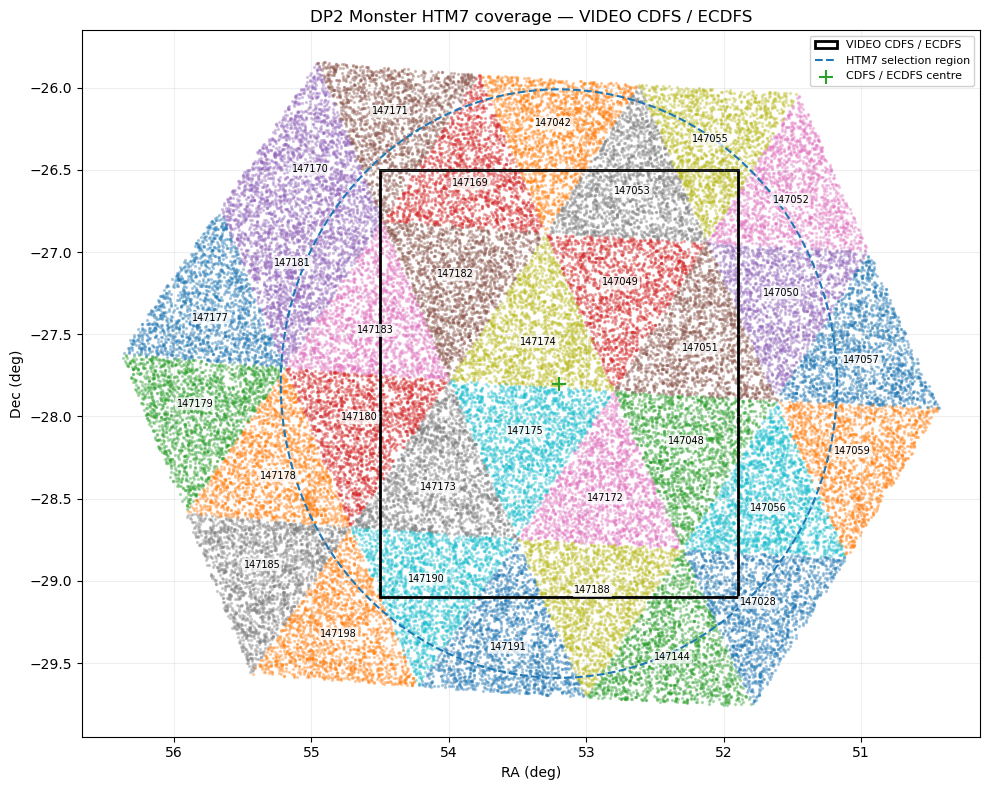

Saved: data/the_monster_20250219/CDFS/VIDEO_CDFS_Monster_coverage.png


In [10]:
fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)

for fits_file in flat_files:

    cat = Table.read(
        fits_file
    )

    ra_values = np.asarray(
        cat[
            "coord_ra"
        ],
        dtype=float,
    )

    dec_values = np.asarray(
        cat[
            "coord_dec"
        ],
        dtype=float,
    )

    if np.nanmax(
        np.abs(
            ra_values
        )
    ) <= (
        2.0
        * np.pi
        + 0.1
    ):
        ra_deg = np.degrees(
            ra_values
        )
        dec_deg = np.degrees(
            dec_values
        )
    else:
        ra_deg = ra_values
        dec_deg = dec_values

    htm7_id = int(
        fits_file.stem.split(
            "_"
        )[
            -1
        ]
    )

    ax.scatter(
        ra_deg,
        dec_deg,
        s=2,
        alpha=0.30,
    )

    ax.text(
        np.median(
            ra_deg
        ),
        np.median(
            dec_deg
        ),
        str(
            htm7_id
        ),
        ha="center",
        va="center",
        fontsize=7,
        bbox=dict(
            boxstyle=(
                "round,pad=0.15"
            ),
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
    )

footprint = Rectangle(
    (
        VIDEO_RA_MIN,
        VIDEO_DEC_MIN,
    ),
    VIDEO_RA_MAX
    - VIDEO_RA_MIN,
    VIDEO_DEC_MAX
    - VIDEO_DEC_MIN,
    fill=False,
    linewidth=2.0,
    label="VIDEO CDFS / ECDFS",
)

ax.add_patch(
    footprint
)

theta = np.linspace(
    0.0,
    2.0
    * np.pi,
    500,
)

ra_circle = (
    RA_CENTER_DEG
    + RADIUS_DEG
    * np.cos(
        theta
    )
    / np.cos(
        np.deg2rad(
            DEC_CENTER_DEG
        )
    )
)

dec_circle = (
    DEC_CENTER_DEG
    + RADIUS_DEG
    * np.sin(
        theta
    )
)

ax.plot(
    ra_circle,
    dec_circle,
    linestyle="--",
    linewidth=1.5,
    label="HTM7 selection region",
)

ax.scatter(
    [
        RA_CENTER_DEG,
    ],
    [
        DEC_CENTER_DEG,
    ],
    marker="+",
    s=90,
    label="CDFS / ECDFS centre",
)

ax.set_xlabel(
    "RA (deg)"
)
ax.set_ylabel(
    "Dec (deg)"
)
ax.set_title(
    "DP2 Monster HTM7 coverage — "
    "VIDEO CDFS / ECDFS"
)
ax.invert_xaxis()
ax.grid(
    alpha=0.2
)
ax.legend(
    fontsize=8,
    framealpha=0.9,
)

fig.tight_layout()

figure_path = (
    work_dir
    / "VIDEO_CDFS_Monster_coverage.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {figure_path}"
)

### Create transfer archives

In [12]:
zip_path = shutil.make_archive(
    "data/the_monster_20250219/CDFS_Monster",
    "zip",
    root_dir=work_dir,
)

print("Saved:", zip_path)

Saved: /home/elham-saremi/notebooks/DP2-Eli/data/the_monster_20250219/CDFS_Monster.zip
